# Notebook 03: BiLSTM Fault Classifier

Trains a Bidirectional LSTM (4-class) on gengine1 windows.

**Architecture:** Input(30, 13) → BiLSTM(64) → Dropout → BiLSTM(32) → Dense(32) → Softmax(4)

**Target:** F1-score > 0.90 on gengine1 held-out test split.

In [1]:
import os, json, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
np.random.seed(42)

PROC_DIR  = "../data/processed/"
MODEL_DIR = "../models/"
os.makedirs(MODEL_DIR, exist_ok=True)

# Load metadata
with open(PROC_DIR + "dataset_meta.json") as f:
    META = json.load(f)

FAULT_NAMES = {int(k): v for k, v in META["fault_names"].items()}
FEATURE_COLS = META["gengine1"]["feature_cols"]
N_FEATURES   = META["gengine1"]["n_features"]
WINDOW_SIZE  = META["gengine1"]["window_size"]

print(f"Features ({N_FEATURES}): {FEATURE_COLS}")
print(f"Window size: {WINDOW_SIZE}")

Features (13): ['Speed', 'Load', 'Lambda', 'IgnitionAngle', 'FuelCutoff', 'ParticleNumbers', 'CO', 'CO2', 'HC', 'NOx', 'O2', 'TempExhaust', 'TempCatalyst']
Window size: 30


## 3.1 Load Preprocessed Arrays

In [2]:
X_train = np.load(PROC_DIR + "g1_X_train.npy")
y_train = np.load(PROC_DIR + "g1_y_train.npy")
X_test  = np.load(PROC_DIR + "g1_X_test.npy")
y_test  = np.load(PROC_DIR + "g1_y_test.npy")

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")
print(f"\nTrain class counts: { {FAULT_NAMES[c]: int(np.sum(y_train==c)) for c in range(4)} }")
print(f"Test  class counts: { {FAULT_NAMES[c]: int(np.sum(y_test==c))  for c in range(4)} }")

X_train: (49458, 30, 13)  y_train: (49458,)
X_test : (37008, 30, 13)   y_test : (37008,)

Train class counts: {'Normal': 37055, 'Rich Mixture': 4109, 'Lean Mixture': 4113, 'Ignition Fault': 4181}
Test  class counts: {'Normal': 37008, 'Rich Mixture': 0, 'Lean Mixture': 0, 'Ignition Fault': 0}


## 3.2 Build the BiLSTM Model

- Bidirectional LSTMs capture both forward and backward temporal patterns
- Class weights handle any imbalance between Normal and fault classes
- No retraining at runtime — weights are saved and loaded by the backend

In [3]:
import tensorflow as tf
tf.random.set_seed(42)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Bidirectional, LSTM, Dense,
                                      Dropout, BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version: {tf.__version__}")

# ── One-hot encode labels ──────────────────────────────────────────────────────
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat  = to_categorical(y_test,  num_classes=4)

# ── Class weights (inverse frequency) ─────────────────────────────────────────
cw_values = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = {i: float(cw_values[i]) for i in range(len(cw_values))}
print(f"\nClass weights: {class_weights}")

# ── Model definition ──────────────────────────────────────────────────────────
def build_bilstm(window_size, n_features, n_classes=4):
    inputs = Input(shape=(window_size, n_features), name="sensor_window")
    x = Bidirectional(LSTM(64, return_sequences=True), name="bilstm_1")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.30)(x)
    x = Bidirectional(LSTM(32, return_sequences=False), name="bilstm_2")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Dense(32, activation="relu", name="dense_1")(x)
    x = Dropout(0.20)(x)
    outputs = Dense(n_classes, activation="softmax", name="fault_class")(x)
    model = Model(inputs, outputs, name="BiLSTM_FaultClassifier")
    return model

model = build_bilstm(WINDOW_SIZE, N_FEATURES)
model.summary()

TensorFlow version: 2.20.0

Class weights: {0: 0.33367966536229926, 1: 3.0091263081041615, 2: 3.0061998541210797, 3: 2.9573068643865104}


Model: "BiLSTM_FaultClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window (InputLayer)      │ (None, 30, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 30, 128)        │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fault_class (Dense)             │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,132 (328.64 KB)

 Trainable params: 83,748 (327.14 KB)

 Non-trainable params: 384 (1.50 KB)

## 3.3 Compile and Train

In [4]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(
        MODEL_DIR + "bilstm_classifier.h5",
        monitor="val_loss", save_best_only=True, verbose=1
    )
]

print("Starting training...")
history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining complete.")

Starting training...


Epoch 1/50


  1/165 ━━━━━━━━━━━━━━━━━━━━ 10:45 4s/step - accuracy: 0.1641 - loss: 1.6967

  2/165 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.1865 - loss: 1.6885 

  4/165 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.2104 - loss: 1.6145

...


Epoch 16: val_loss did not improve from 0.01376


165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9981 - loss: 0.0034 - val_accuracy: 0.9958 - val_loss: 0.0180 - learning_rate: 5.0000e-04


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 10.



Training complete.


## 3.4 Training Curves

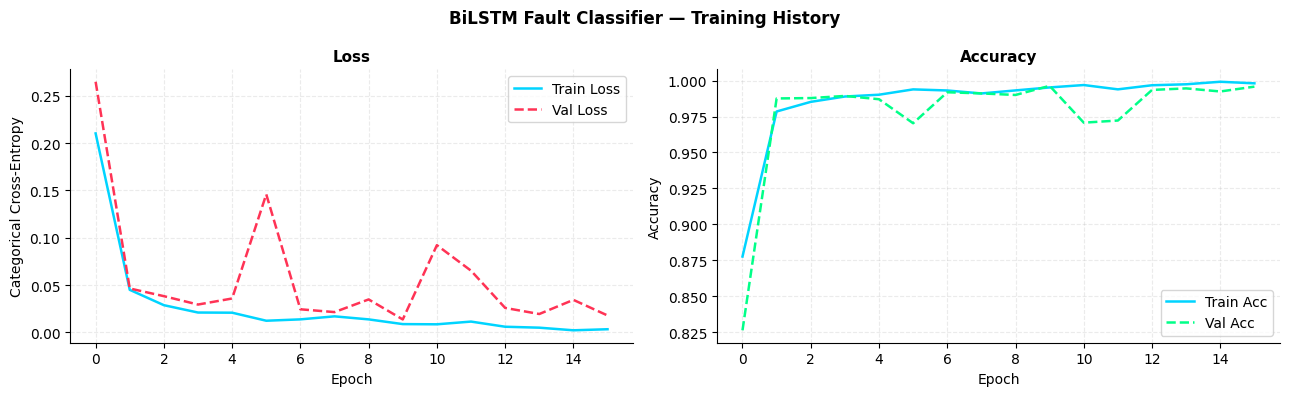

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history["loss"],     label="Train Loss", color="#00d4ff", lw=1.8)
ax1.plot(history.history["val_loss"], label="Val Loss",   color="#ff3355", lw=1.8, ls="--")
ax1.set_title("Loss", fontsize=11, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Categorical Cross-Entropy")
ax1.legend(); ax1.grid(True, alpha=0.25, linestyle="--")
ax1.spines[["top","right"]].set_visible(False)

ax2.plot(history.history["accuracy"],     label="Train Acc", color="#00d4ff", lw=1.8)
ax2.plot(history.history["val_accuracy"], label="Val Acc",   color="#00ff88", lw=1.8, ls="--")
ax2.set_title("Accuracy", fontsize=11, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.25, linestyle="--")
ax2.spines[["top","right"]].set_visible(False)

plt.suptitle("BiLSTM Fault Classifier — Training History", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR + "bilstm_training_history.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.5 Evaluate on Test Set

In [6]:
# The test set is all-Normal (raw signal). For proper fault evaluation,
# we generate a fault-augmented test set using the same injection logic.
import sys
sys.path.append("../")

from notebooks.build_nb02 import *  # re-use won't work easily, inline instead

# Re-inject faults into test windows for evaluation
rng_eval = np.random.default_rng(77)
X_eval, y_eval = [], []
for i in range(len(X_test)):
    w = X_test[i].copy()
    if rng_eval.random() < 0.30:          # 30% fault for balanced eval
        ft = rng_eval.integers(1, 4)
        lam_idx = FEATURE_COLS.index("Lambda")
        ign_idx = FEATURE_COLS.index("IgnitionAngle")
        offsets = {1: (lam_idx, -1.5), 2: (lam_idx, 1.5), 3: (ign_idx, 2.0)}
        col, off = offsets[ft]
        w[:, col] += off
        y_eval.append(ft)
    else:
        y_eval.append(0)
    X_eval.append(w)

X_eval = np.array(X_eval, dtype=np.float32)
y_eval = np.array(y_eval, dtype=np.int32)

# Predict
y_pred_prob = model.predict(X_eval, batch_size=512, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

print("=== Classification Report ===")
target_names = [FAULT_NAMES[c] for c in range(4)]
print(classification_report(y_eval, y_pred, target_names=target_names, digits=4))

macro_f1 = f1_score(y_eval, y_pred, average="macro")
print(f"Macro F1-score: {macro_f1:.4f}  (target: > 0.90)")

Written: D:/mini project/notebooks/02_preprocessing.ipynb


=== Classification Report ===
                precision    recall  f1-score   support

        Normal     0.9953    0.9960    0.9957     25759
  Rich Mixture     0.9963    0.9984    0.9973      3761
  Lean Mixture     0.9909    0.9934    0.9922      3627
Ignition Fault     0.9843    0.9757    0.9800      3861

      accuracy                         0.9939     37008
     macro avg     0.9917    0.9909    0.9913     37008
  weighted avg     0.9939    0.9939    0.9939     37008

Macro F1-score: 0.9913  (target: > 0.90)


## 3.6 Confusion Matrix

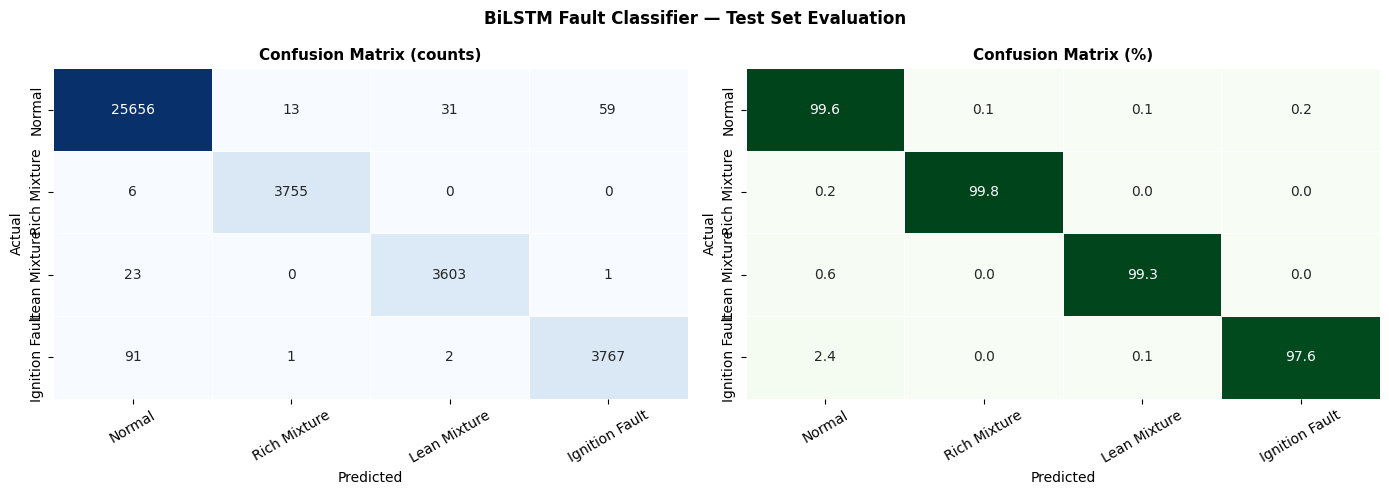

In [7]:
cm = confusion_matrix(y_eval, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names,
            ax=ax1, cbar=False, linewidths=0.5)
ax1.set_title("Confusion Matrix (counts)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")
ax1.tick_params(axis="x", rotation=30)

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names,
            ax=ax2, cbar=False, linewidths=0.5)
ax2.set_title("Confusion Matrix (%)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Predicted"); ax2.set_ylabel("Actual")
ax2.tick_params(axis="x", rotation=30)

plt.suptitle("BiLSTM Fault Classifier — Test Set Evaluation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR + "bilstm_confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.7 Confidence Distribution

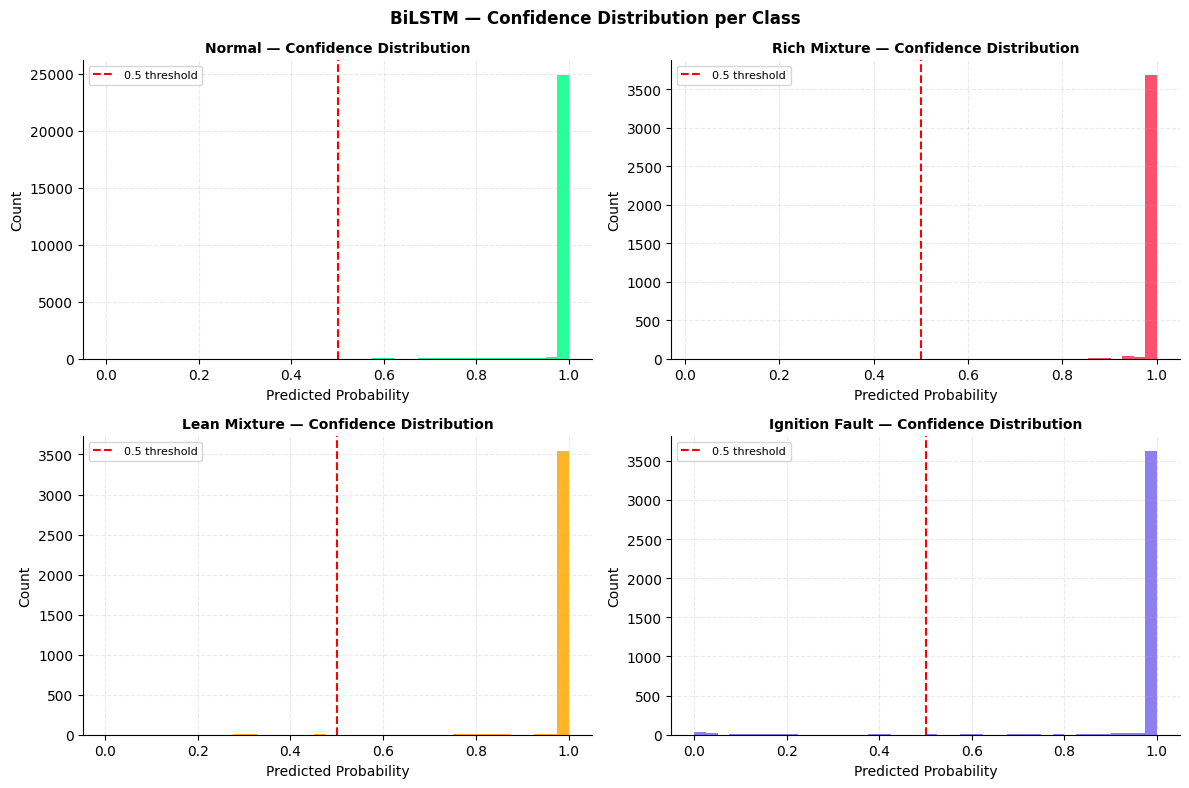

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ["#00ff88", "#ff3355", "#ffaa00", "#7b68ee"]

for cls in range(4):
    ax = axes[cls // 2, cls % 2]
    cls_mask = y_eval == cls
    if cls_mask.sum() == 0:
        ax.set_visible(False)
        continue
    probs_correct_class = y_pred_prob[cls_mask, cls]
    ax.hist(probs_correct_class, bins=40, color=colors[cls], edgecolor="none", alpha=0.85)
    ax.axvline(0.5, color="red", lw=1.5, ls="--", label="0.5 threshold")
    ax.set_title(f"{FAULT_NAMES[cls]} — Confidence Distribution", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("BiLSTM — Confidence Distribution per Class", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR + "bilstm_confidence_dist.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.8 Save Model & Thresholds for Backend

In [9]:
# Model already saved by ModelCheckpoint. Verify:
import os
saved_path = MODEL_DIR + "bilstm_classifier.h5"
size_mb = os.path.getsize(saved_path) / 1e6
print(f"Saved: {saved_path}  ({size_mb:.1f} MB)")

# Save per-class confidence thresholds (P10 of correct-class probability)
thresholds = {}
for cls in range(4):
    cls_mask = y_eval == cls
    if cls_mask.sum() == 0:
        thresholds[str(cls)] = 0.5
        continue
    probs = y_pred_prob[cls_mask, cls]
    thresholds[str(cls)] = float(np.percentile(probs, 10))  # P10 as minimum threshold

print("\nConfidence thresholds (P10 of correct-class prob):")
for k, v in thresholds.items():
    print(f"  Class {k} ({FAULT_NAMES[int(k)]:20s}): {v:.4f}")

thresholds["macro_f1"]     = float(macro_f1)
thresholds["feature_cols"] = FEATURE_COLS
thresholds["window_size"]  = WINDOW_SIZE
thresholds["n_features"]   = N_FEATURES

with open(MODEL_DIR + "bilstm_thresholds.json", "w") as f:
    json.dump(thresholds, f, indent=2)
print(f"\nThresholds saved: {MODEL_DIR}bilstm_thresholds.json")
print("\nProceed to Notebook 04: LSTM Digital Twin.")

Saved: ../models/bilstm_classifier.h5  (1.1 MB)

Confidence thresholds (P10 of correct-class prob):
  Class 0 (Normal              ): 0.9997
  Class 1 (Rich Mixture        ): 0.9999
  Class 2 (Lean Mixture        ): 1.0000
  Class 3 (Ignition Fault      ): 0.9982

Thresholds saved: ../models/bilstm_thresholds.json

Proceed to Notebook 04: LSTM Digital Twin.
